In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import K-Means clustering and StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set a random seed so the dataset is the same every time
np.random.seed(42)

# Number of books in the dataset
n_books = 200

# Create a sample book dataset
data = pd.DataFrame({
    'Title': [f'Book_{i}' for i in range(n_books)],
    'Average_Rating': np.random.uniform(2.5, 4.9, n_books).round(2),
    'Readability_Score': np.random.uniform(40, 95, n_books).round(1),
    'Price': np.random.uniform(5, 35, n_books).round(2),
    'Page_Count': np.random.randint(120, 850, n_books),
    'Genre': np.random.randint(0, 5, n_books)
})

# Display the first five rows of the dataset
print("Dataset Preview")
print(data.head())

Dataset Preview
    Title  Average_Rating  Readability_Score  Price  Page_Count  Genre
0  Book_0            3.40               75.3   8.09         124      1
1  Book_1            4.78               44.6  32.08         585      2
2  Book_2            4.26               48.9  20.16         723      4
3  Book_3            3.94               89.4  29.79         801      0
4  Book_4            2.87               73.4  14.60         653      0


In [2]:
# Select only the numerical features for clustering
features = data[['Average_Rating',
                 'Readability_Score',
                 'Price',
                 'Page_Count',
                 'Genre']]

# Display the selected features
print(features.head())

   Average_Rating  Readability_Score  Price  Page_Count  Genre
0            3.40               75.3   8.09         124      1
1            4.78               44.6  32.08         585      2
2            4.26               48.9  20.16         723      4
3            3.94               89.4  29.79         801      0
4            2.87               73.4  14.60         653      0


In [3]:
# Create a StandardScaler object
scaler = StandardScaler()

# Scale the features so they all have equal importance
scaled_features = scaler.fit_transform(features)

/lib/python3.14/site-packages/threadpoolctl.py:1135: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


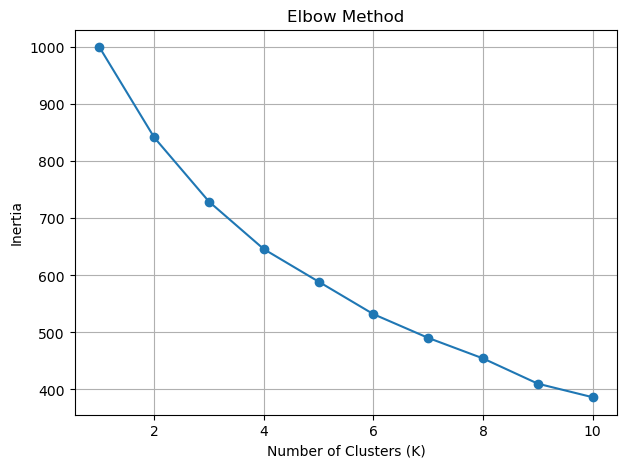

In [4]:
# Store inertia values for each value of K
inertia = []

# Try K values from 1 to 10
K = range(1, 11)

# Train a K-Means model for each K
for k in K:

    # Create the model
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model to the scaled data
    model.fit(scaled_features)

    # Save the inertia value
    inertia.append(model.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(7,5))
plt.plot(K, inertia, marker='o')

# Add labels and title
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# Show grid lines
plt.grid(True)

# Display the graph
plt.show()

In [5]:
# Create the K-Means model with 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the model and assign each book to a cluster
data['Cluster'] = kmeans.fit_predict(scaled_features)

# Display the updated dataset
print(data.head())

    Title  Average_Rating  Readability_Score  Price  Page_Count  Genre  \
0  Book_0            3.40               75.3   8.09         124      1   
1  Book_1            4.78               44.6  32.08         585      2   
2  Book_2            4.26               48.9  20.16         723      4   
3  Book_3            3.94               89.4  29.79         801      0   
4  Book_4            2.87               73.4  14.60         653      0   

   Cluster  
0        2  
1        3  
2        3  
3        3  
4        0  


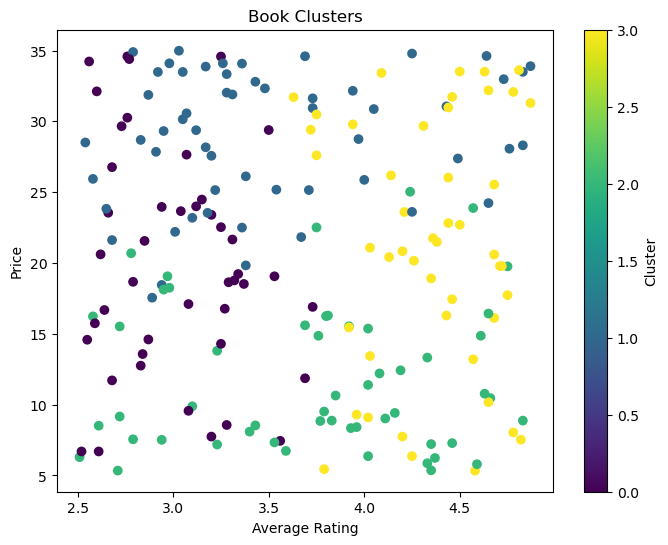

In [6]:
# Create a scatter plot
plt.figure(figsize=(8,6))

# Plot Average Rating vs Price
plt.scatter(
    data['Average_Rating'],
    data['Price'],
    c=data['Cluster'],      # Color points based on cluster
    cmap='viridis'
)

# Add labels and title
plt.xlabel("Average Rating")
plt.ylabel("Price")
plt.title("Book Clusters")

# Display the cluster color legend
plt.colorbar(label="Cluster")

# Show the graph
plt.show()

In [7]:
# Calculate the average values for each cluster
cluster_summary = data.groupby('Cluster')[[
    'Average_Rating',
    'Readability_Score',
    'Price',
    'Page_Count',
    'Genre'
]].mean()

# Display the summary
print(cluster_summary)

         Average_Rating  Readability_Score      Price  Page_Count     Genre
Cluster                                                                    
0              3.016591          65.279545  19.981136  680.931818  2.318182
1              3.503214          61.353571  28.872321  296.892857  1.767857
2              3.753774          76.845283  11.824528  316.037736  2.188679
3              4.350000          67.389362  21.305106  669.851064  1.595745


In [8]:
# Select a book for recommendation
selected_book = "Book_15"

# Find which cluster the selected book belongs to
selected_cluster = data.loc[
    data['Title'] == selected_book,
    'Cluster'
].values[0]

# Print the selected book information
print("Selected Book:", selected_book)
print("Cluster:", selected_cluster)

# Find other books in the same cluster
recommendations = data[
    (data['Cluster'] == selected_cluster) &
    (data['Title'] != selected_book)
]

# Display the first 10 recommended books
print("\nRecommended Books:")
print(recommendations[['Title',
                       'Average_Rating',
                       'Price',
                       'Genre']].head(10))

Selected Book: Book_15
Cluster: 1

Recommended Books:
      Title  Average_Rating  Price  Genre
5    Book_5            2.87  31.87      0
8    Book_8            3.94  32.16      1
11  Book_11            4.83  33.50      2
13  Book_13            3.01  22.20      2
18  Book_18            3.54  25.18      3
19  Book_19            3.20  27.57      2
20  Book_20            3.97  28.75      3
21  Book_21            2.83  28.69      4
23  Book_23            3.38  19.83      0
27  Book_27            3.73  31.63      0
